In [1]:
import numpy as np
import pandas as pd
import json
import pickle
import sys, os
import re
import torch
print(torch.__version__)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import plotly.express as px

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
print(module_path)

# from light_transformer_analysis import *
from explainability_analysis.transformer_analysis import *
from explainability_analysis.crop_spectral_signature_analysis import *
from explainability_analysis.visualization_functions import *
from explainability_analysis.visualization_constants import *

dataset = 'BavarianCrops' # 'DENETHOR'
# dataset = 'DENETHOR' # 'DENETHOR'
num_heads = [1,4,16]

if dataset == 'BavarianCrops':
    num_classes = 12
    tae_stamps = ['1746218621', '1746227963', '1746237488']
    ltae_stamps = ['1746185338', '1746194875', '1746198974']
    # ltae_new_stamps = ['1746219370', '1746224241', '1746236109'] # old decoder
    ltae_new_stamps = ['1746305890', '1746317037', '1746328377'] # new decoder
elif dataset == 'DENETHOR':
    num_classes = 9
    tae_stamps = ['1746110753', '1746112148', '1746184554']
    ltae_stamps = ['1746183324', '1746183556', '1746183792']
    # ltae_new_stamps = ['1746219326', '1746219754', '1746220254'] # old decoder
    ltae_new_stamps = ['1746305855', '1746306298', '1746306746'] # new decoder

root = f"/home/luca/luca_docker/results/crop-type-classification-explainability/presentation/{num_classes}_classes"
all_timestamps = [tae_stamps, ltae_stamps, ltae_new_stamps]
models = ['tae', 'ltae', 'ltae_new']

2.0.0+cu117
/home/luca/luca_docker/crop-type-classification-explainability


In [2]:
tex_fonts_false = {
    #source: https://jwalton.info/Embed-Publication-Matplotlib-Latex/
    # Use LaTeX to write all text
    "text.usetex": False,               # --> tex package not found
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    #"axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    'text.latex.preamble': r"\usepackage{amsmath}"
}

plt.rcParams.update(tex_fonts_false)

In [5]:
# Define the base path
base_path = f"/home/luca/luca_docker/results/crop-type-classification-explainability/paper/{num_classes}_classes/ltae/right_padding/obs_aq_date/concatenate_heads=False/"

# List all folders in the base path
folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]

classification_metrics = []

# Extract heads and emb_dim values
extracted_values = []
for folder in folders:
    match = re.search(r'heads=(\d+),emb_dim=(\d+)', folder)
    if match:
        heads = int(match.group(1))
        emb_dim = int(match.group(2))

        model_path = os.path.join(base_path, folder, 'WCE,gamma=0/focal_loss_ratio=80/all_dates')
        if os.path.isdir(model_path):
            tmstp = os.listdir(model_path)[0]
        else:
            tmstp = ""

        if  os.path.isdir(os.path.join(model_path, tmstp, "predictions")):
            class_metrics = pd.read_csv(os.path.join(model_path, tmstp, "predictions/classification_metrics.csv"))
            class_metrics['num_heads'] = heads
            class_metrics['E'] = emb_dim
            class_metrics['scale_factor'] = emb_dim // heads

            classification_metrics.append(class_metrics)
classification_metrics_df = pd.concat(classification_metrics)
classification_metrics_df = classification_metrics_df[~classification_metrics_df['E'].isin([2048])]
display(classification_metrics_df.sort_values(by='num_heads'))#, ascending=False))


,loss,accuracy,average_class_accuracy,kappa,precision,recall,f1,num_heads,E,scale_factor
0,0.343308,0.873104,0.589193,0.789522,0.547342,0.589193,0.563168,16,512,32
0,0.306845,0.879998,0.591725,0.798954,0.549300,0.591725,0.561883,16,1024,64
0,0.354327,0.874253,0.576835,0.789863,0.544460,0.576835,0.555477,16,128,8
0,0.350645,0.868509,0.586208,0.783843,0.547273,0.586208,0.559410,16,256,16
0,0.321583,0.871841,0.664138,0.792606,0.596956,0.664138,0.621079,32,512,16
0,0.308735,0.881664,0.642142,0.805986,0.578458,0.642142,0.604663,32,1024,32
0,0.356427,0.866958,0.591847,0.781800,0.539197,0.591847,0.555382,32,128,4
0,0.317172,0.883732,0.615248,0.806740,0.628373,0.615248,0.602385,32,256,8
0,0.289855,0.886719,0.667218,0.813954,0.639599,0.667218,0.636964,64,1024,16
0,0.306021,0.875862,0.670683,0.799452,0.680395,0.670683,0.652708,64,512,8


In [7]:
classification_metrics = []

for h_idx, h in enumerate(num_heads):
    for i, model_stamps in enumerate(all_timestamps):
        model = models[i].split('_')[0]
        tmsp = model_stamps[h_idx]
        model_path = f"{model}/right_padding/obs_aq_date/layers=1,heads={h},emb_dim=128/focal_loss_ratio=100/all_dates/{tmsp}"
        class_metrics = pd.read_csv(os.path.join(root, model_path, "predictions/classification_metrics.csv"))
        class_metrics['num_heads'] = h
        class_metrics['model'] = models[i]

        classification_metrics.append(class_metrics)
classification_metrics_df = pd.concat(classification_metrics)

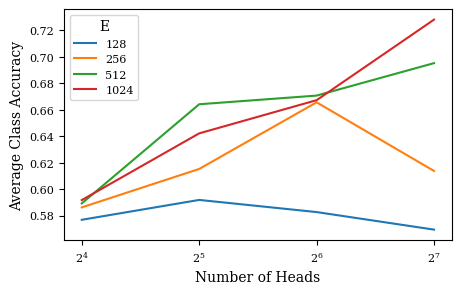

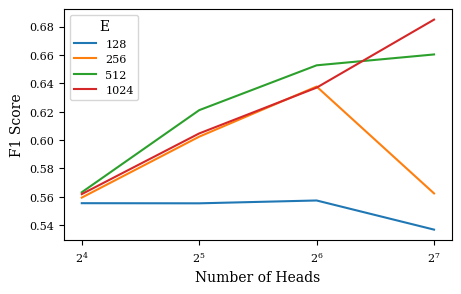

In [6]:
# display(classification_metrics_df)

fig = plt.figure(figsize=(5, 3))
ax = sns.lineplot(data=classification_metrics_df, x='num_heads', y='average_class_accuracy', hue='E', palette="tab10", legend=True)
plt.xscale('log', base=2)
plt.ylabel('Average Class Accuracy')
plt.xlabel('Number of Heads')
plt.show()

fig = plt.figure(figsize=(5, 3))
ax1 = sns.lineplot(data=classification_metrics_df, x='num_heads', y='f1', hue='E', palette="tab10", legend=True)
plt.xscale('log', base=2)
plt.ylabel('F1 Score')
plt.xlabel('Number of Heads')
plt.show()

# classification_metrics_heads_df = classification_metrics_df[classification_metrics_df['num_heads'] == 16].set_index('model')
# display(classification_metrics_heads_df[['accuracy', 'average_class_accuracy', 'f1']])

In [15]:
loss_fn_weights = [0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
att_ndvi_pred_tmsp = ['1746358062', '1746358523', '1746358984', '1746359462', '1746359936', '1746360405', '1746360876', '1746361344', '1746306746']
# Run experiment again for NDVI predictions on encoded output
out_ndvi_pred_tmsp = ['1746364286', '1746364733', '1746365187', '1746365582', '1746366040', '1746366494', '1746366948', '1746367400', '1746306746']

classification_metrics = []

for alpha_idx, alpha in enumerate(loss_fn_weights):
    # tmsp = att_ndvi_pred_tmsp[alpha_idx]
    tmsp = out_ndvi_pred_tmsp[alpha_idx]
    model_path = f"ltae/right_padding/obs_aq_date/layers=1,heads=16,emb_dim=128/focal_loss_ratio={int(alpha*100)}/all_dates/{tmsp}"
    class_metrics = pd.read_csv(os.path.join(root, model_path, "predictions/classification_metrics.csv"))
    class_metrics['alpha'] = alpha

    classification_metrics.append(class_metrics)
classification_metrics_alpha_df = pd.concat(classification_metrics)

,loss,accuracy,average_class_accuracy,kappa,precision,recall,f1,alpha
0,0.143235,0.166911,0.111111,0.000000,0.018546,0.111111,0.031786,0.0
0,0.371284,0.600587,0.526118,0.496592,0.598352,0.526118,0.474379,0.2
0,0.504419,0.611845,0.534030,0.499106,0.563021,0.534030,0.476922,0.4
0,0.696193,0.604503,0.573974,0.505166,0.588161,0.573974,0.476042,0.5
0,0.804290,0.568282,0.468406,0.450043,0.489939,0.468406,0.407288,0.6
0,0.672004,0.644640,0.565556,0.550306,0.600880,0.565556,0.550008,0.7
0,1.118224,0.579050,0.518711,0.468528,0.609553,0.518711,0.450787,0.8
0,1.066950,0.600587,0.576332,0.500283,0.611782,0.576332,0.488704,0.9
0,0.960688,0.668135,0.626606,0.584909,0.620958,0.626606,0.585605,1.0


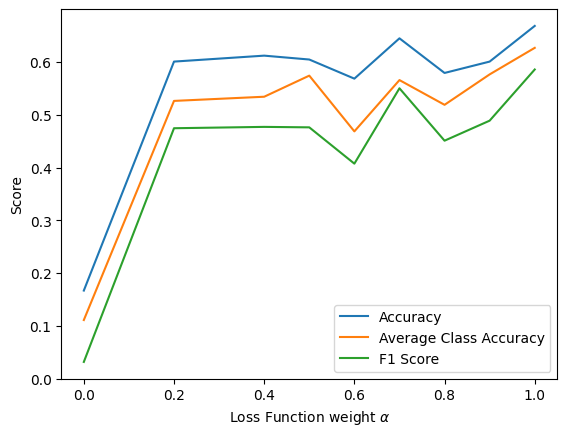

In [16]:
display(classification_metrics_alpha_df)

fig = plt.figure()
ax = sns.lineplot(data=classification_metrics_alpha_df, x='alpha', y='accuracy', label='Accuracy')
ax = sns.lineplot(data=classification_metrics_alpha_df, x='alpha', y='average_class_accuracy', label='Average Class Accuracy')
ax = sns.lineplot(data=classification_metrics_alpha_df, x='alpha', y='f1', label='F1 Score')
plt.ylabel('Score')
plt.xlabel(r'Loss Function weight $\alpha$')
plt.show()

# fig = plt.figure()
# ax1 = sns.lineplot(data=classification_metrics_alpha_df, x='alpha', y='f1')
# plt.ylabel('F1 Score')
# plt.xlabel(r'Loss Function weight $\alpha$')
# plt.show()